# Digging in the Noise

Now that I am sure that I can see the signals, it is time to take a deeper dive into the noise. I am particularly interested in the question of whether there are actual edges hiding in there or if we are just looking at electronic noise. I propose to start by looking much more closely at the left-hand end of the energy histogram.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [7]:
class Kernel:
    def __init__(self, n_rise, n_flat, dt=0.032):
        self.rise = int(n_rise)
        self.flat = int(n_flat)
        self.kernel = np.zeros(2 * n_rise + n_flat)
        mag = 1.0 / n_rise
        self.kernel[:n_rise] = mag
        self.kernel[n_rise + n_flat:] = -mag
        self.offset = (n_rise + int((n_flat + 0.5)/2)) * dt

I am going to take the opportunity to build all the energy tools into the reduced data class. That will allow me to pull out some features as class variables and to eliminate other arguments altogether since the methods automatically have access to the class variables.

In [15]:
class ReducedData:
    #
    # Class variables
    #
    dt = 0.032 # times in microseconds
    fit_gap = 200
    debug = False
    edge_rise = 40
    edge_flat = 3
    #
    # Constructor
    #
    def __init__(self, filename):
        with h5py.File(filename, "r") as f:
            nkey = len(f.keys())
            if nkey != 1:
                raise ValueError('run file contains {nkey} groups not just 1.')
            group = f['events']
            wave = group['waveform']
            times = group['timestamp_us']
            triggers = group['trigger_id']
            energies = group['energy']
            self.nevents, self.nchannel, self.npoint = wave.shape
            self.waveforms = wave[:, :, :]
            self.trap_energies = energies[:, :]
            self.triggers = triggers[:]
            self.event_times = times[:]
        self.energy_tuples = None
        self.edge_kernel = Kernel(ReducedData.edge_rise, ReducedData.edge_flat)
        self.times = np.arange(0, self.npoint * ReducedData.dt, ReducedData.dt)

    # Plot one waveform on a new graph
    def plot_wave(self, evt, chan):
        fig, ax = plt.subplots(figsize=(8,6))
        self.plot_wave_on(ax, evt, chan)
        return ax

    # Add one waveform plot to an existing graph
    def plot_wave_on(self, axis, evt_no, chan_no):
        axis.plot(self.times, self.waveforms[evt_no, chan_no, :],
                '.', label=f'({evt_no}, {chan_no})')

    # Finds an edge in a single waveform
    def find_one_edge(self, evt_no, chan_no, plot=False):
        array = self.waveforms[evt_no, chan_no, :]
        pulse = np.convolve(array, self.edge_kernel.kernel, mode='valid')
        npp = len(pulse)
        energy = -np.min(pulse)
        e_index = np.argmin(pulse)
        kern = self.edge_kernel
        if plot:
            ax = self.plot_wave(evt_no, chan_no)
            ax.plot(self.times[:npp] + kern.offset, pulse + np.average(array[:100]))
        return energy, e_index

    # Finds all the edges in a single channel
    def find_channel_edges(self, chan_no, plot=False):
        mins = np.zeros(self.nevents)
        edges = np.zeros(self.nevents)
        for i in range(self.nevents):
            mins[i], edges[i] = self.find_one_edge(i, chan_no, plot=plot)
        return mins, edges

    # find energy from a given wave
    # pass in edge index if known
    def find_one_energy(self, evt_no, chan_no, index=None, full=False, plot = False):
        if index is not None:
            edge_index = int(index)
        else:
            e_guess, edge_index = self.find_edge(evt_no, chan_no, plot=plot)
        gap = ReducedData.fit_gap
        waveform = self.waveforms[evt_no, chan_no, :]
        index_left_end = edge_index - int(gap / 4)
        left = np.average(waveform[:index_left_end])
        left_fit = np.zeros_like(waveform) + left
        index_right_end = edge_index + int(3 * gap / 4)
        if ReducedData.debug:
            print(f'left to {index_left_end}, right from {index_right_end}')
        rtimes = times[index_right_end:]
        rwave = waveform[index_right_end:]
        right_coefs = np.polyfit(rtimes, rwave, 3)
        if ReducedData.debug:
            print(f'coefs={right_coefs}')
        right_poly = np.poly1d(right_coefs)
        right_fit = right_poly(times)
        if plot:
            r_fitted = right_poly(rtimes)
            ax = self.plot_wave(evt_no, chan_no)
            ax.plot(times[:index_left_end], left_fit[:index_left_end])
            ax.plot(rtimes, r_fitted)
            ax.title(f'Fit to ({evt_no, chan_no} energy {energy}')
        energy = left - right_fit[edge_index]
        if full:
            return energy, left_fit, right_fit, edge_index
        else:
            return energy

    # Find the energies from all the events in a single channel.
    # Returns a tuple containing
    # [0] array of all the energies from events where the
    #     edge is found at sample 7500 or lower.
    # [1] array of the estimated energies for every channel
    # [2] array of the edge location for every channel 
    def find_channel_energies(self, chan_no, edges=None, plot=False):
        if edges is None:
            mins, edges = self.find_channel_edges(chan_no, plot=plot)
        if len(edges) != self.nevents:
            raise ValueError(f'number of edges {len(edges)} does not match number of events {self.nevents}')
        out_index = 0
        energies = np.zeros(self.nevents)
        for evt_no in range(self.nevents):
            if edges[evt_no] < 7501:
                e = self.find_one_energy(evt_no, chan_no, edges[evt_no], plot=plot)
                energies[out_index] = e
                out_index += 1
        return energies[:out_index], mins, edges

    # Find all the energies for all events in all channels!
    # returns a list of tuples from find_channel_edge which is also
    # saved in self
    # Because this can take a long time it prints the channel number 
    # as it completes a channel.
    def find_energies(self, plot=False, subplot = False):
        self.energy_tuples = []
        for chan in range(21):
            energies, mins, edges  = find_channel_energies(chan, plot=subplot)
            print(i)
            self.energy_tuples.append((energies, mins, edges))
            if plot:
                plt.hist(energies, bins=201)
        if plot:
            plt.ylim([0, 50])
        return self.energy_tuples

There, that is rather a lot of code and I am also saving it in the ReducedData.py file. We start by reading in the data.

In [16]:
rd = ReducedData('run_0-100_combined_r125_g24_roi_thr1500.h5')

## Into the noise

To keep times down I am going to start with a single channel's worth of data. I start by pulling the energy estimates and edge positions.

In [34]:
mins, edges = rd.find_channel_edges(0)

Now I look for all of the events that do not obviously contain an edge. I am going to use min=500 as the cut-off.

In [35]:
noise_indices = []
for evt in range(rd.nevents):
    if mins[evt] < 500:
        noise_indices.append(evt)
print(len(noise_indices))

8193


In [36]:
print(rd.nevents)

8396


OK, so almost all of them are noise! Let's see if we can histogram just the low ones that we found.

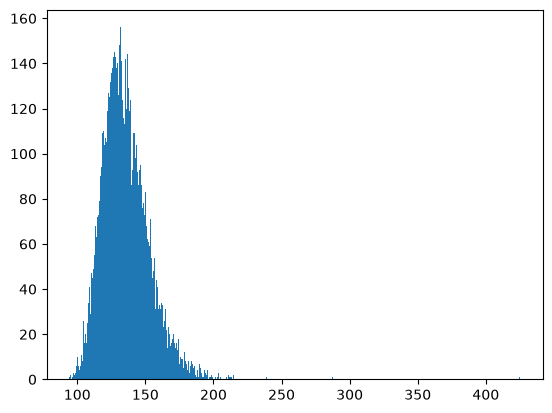

In [37]:
h1 = plt.hist(mins[noise_indices], bins=501)

Well, that is interesting. There are almost no events above about 200, which is about twice the standard deviation of the typical noise. In fact let's test that.

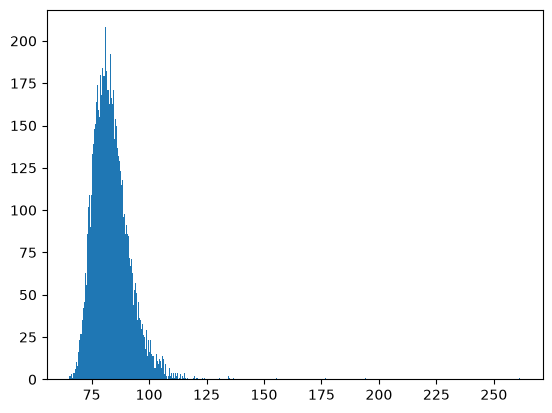

In [38]:
std_devs=[]
for i in noise_indices:
    sd = np.std(rd.waveforms[i, 0, :])
    std_devs.append(sd)
h2 = plt.hist(std_devs, bins=501)

So my noise energies are all clustered around twice the standard deviation of the noise. This is consistent with there being no actual events here.

What if we repeat the analysis across all the channels?

In [39]:
energies = np.array([0])

0 8193
1 7497
2 7415
3 8396
4 7550
5 8160
6 8193
7 8201
8 8193
9 8396
10 8167
11 8216
12 8196
13 8153
14 7649
15 7591
16 8167
17 8166
18 7455
19 7480
20 8164


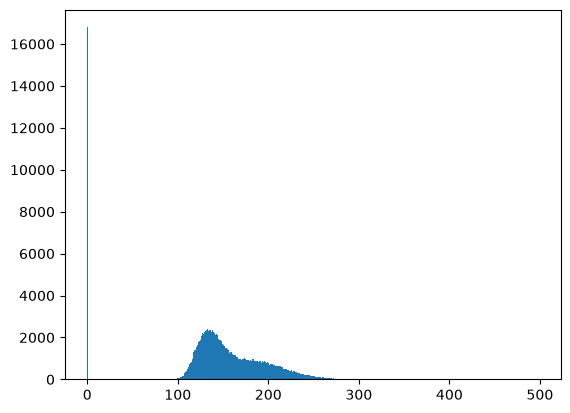

In [40]:
for ch in range(21):
    mins, edges = rd.find_channel_edges(ch)
    noise_indices = []
    for evt in range(rd.nevents):
        if mins[evt] < 500:
            noise_indices.append(evt)
    print(ch, len(noise_indices))
    energies = np.append(energies, mins[noise_indices])
h1 = plt.hist(energies, bins=501)

Oooh, look at that! There are two clear components to the noise. Let's blow it up a bit.

(0.0, 2500.0)

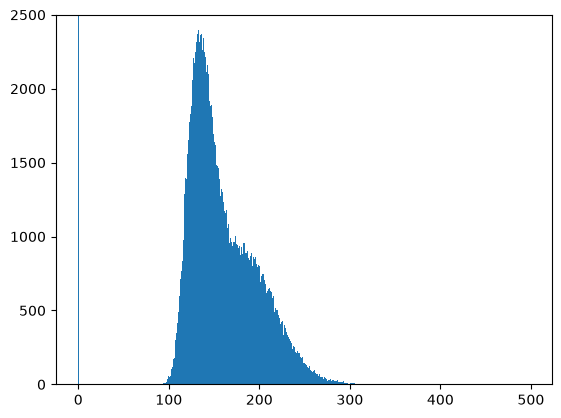

In [41]:
h2 = plt.hist(energies, bins=501)
plt.ylim([0, 2500])

Well, that is clearly two superimposed distributions. The tall one I am pretty certain is the underlying electronic noise. The lower, wider one is the interesting one. We ought to be able to look at kind by pulling out only those waveforms that have energies in the 200-300 ADC unit range, of which there were none in channel 0. Let's try channel 1.

In [42]:
mins1, edges1 = rd.find_channel_edges(1)
new_indices = []
for evt in range(rd.nevents):
    if mins1[evt] < 300 and mins1[evt] >= 200:
        new_indices.append(evt)
print(len(new_indices))

1361


(0.0, 50.0)

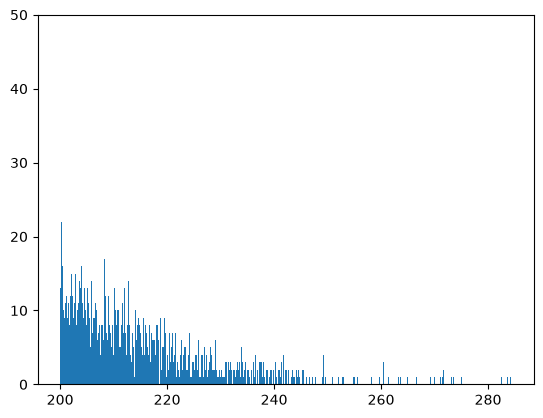

In [43]:
h3 = plt.hist(mins1[new_indices], bins=501)
plt.ylim([0, 50])

Well that looks about right. Now lets plot a few of these waveforms.

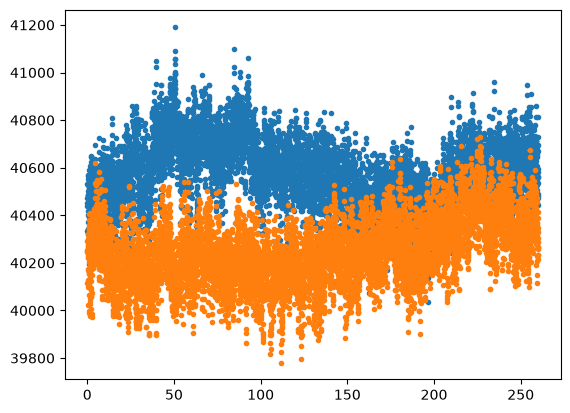

In [51]:
times = np.arange(0, rd.npoint * ReducedData.dt, ReducedData.dt)
for i in range(2):
    plt.plot(times, rd.waveforms[new_indices[i], 1, :], '.')

That is not very enlightening. I am going to try something different.

214.59999999999962 1902
218.7999999999958 1452
217.29999999999944 6383
238.00000000000085 5775
222.65000000000177 4943


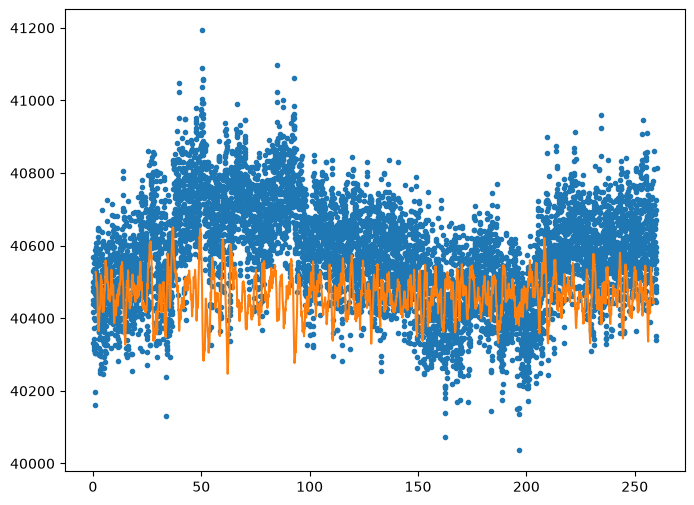

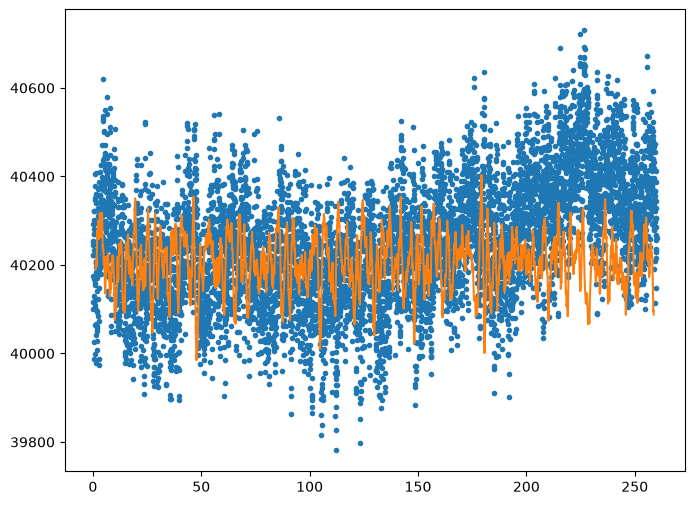

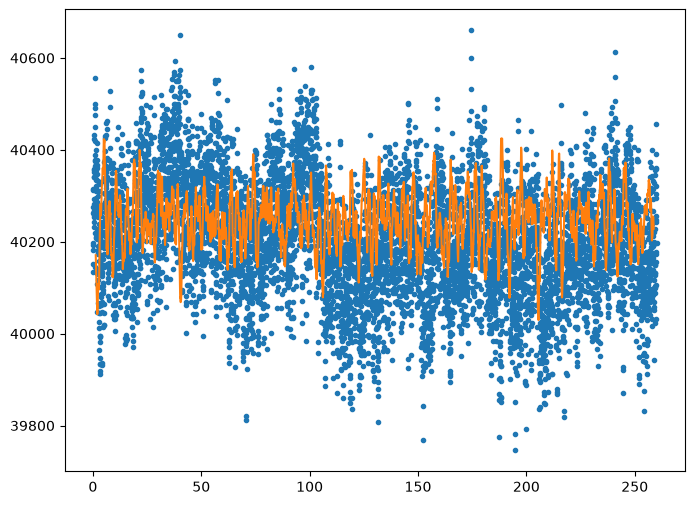

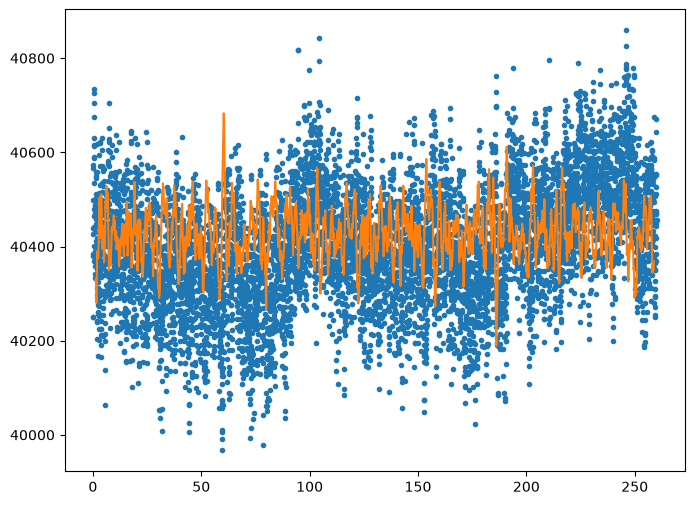

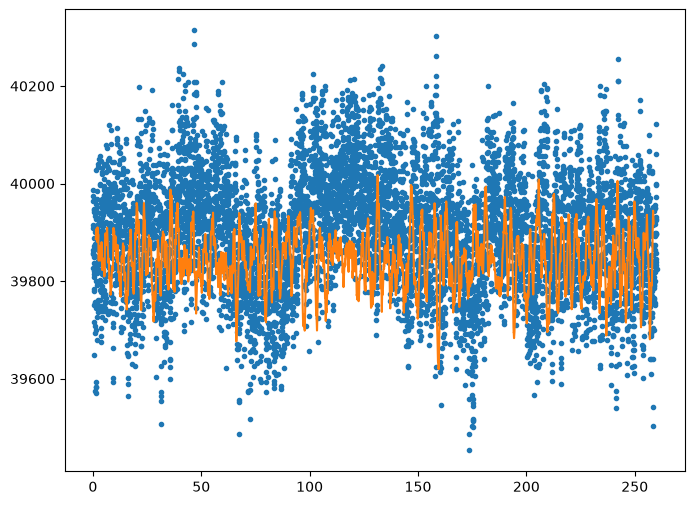

In [58]:
for i in range(5):
    e,i = rd.find_one_edge(new_indices[i], 1, plot=True)
    print(e,i)

I will note that most of these show signs of a clear periodic component in the noise. Let's run a bunch of spectra.

In [63]:
nspect = 40
spectra = []
for i in range(nspect):
    ft = np.fft.rfft(rd.waveforms[new_indices[i], 1, :])
    spect = np.abs(ft)**2
    spectra.append(spect)

(0.0, 2.0)

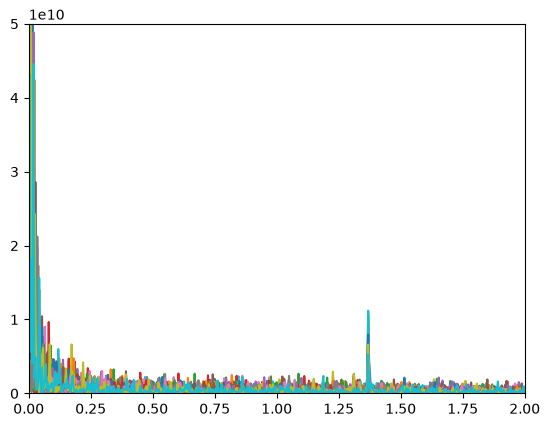

In [66]:
freqs = np.fft.rfftfreq(rd.npoint, ReducedData.dt)
for i in range(nspect):
    plt.plot(freqs[1:], spectra[i][1:])
plt.ylim([0, 5e10])
plt.xlim([0, 2])

So there is a serious noise spike present in a number of these at about 1.35 MHz.

And if I sum the spectra instead (and divide them down to make the numbers a bit more sensible)?

In [67]:
avg_spect = spectra[0]/1e11
for i in range(nspect-1):
    avg_spect = avg_spect + spectra[i+1]/1e11


(0.0, 2.0)

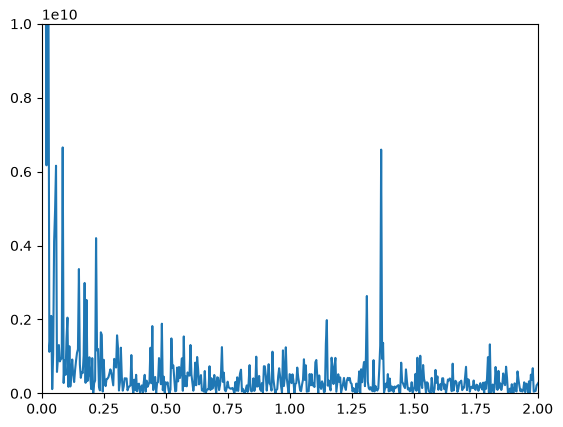

In [72]:
plt.plot(freqs[1:], spectra[i][1:])
plt.ylim([0, 1e10])
plt.xlim([0, 2])

There are a number of serious spikes there. If this is present across much of the data then it is probably a significant menace to the resolution. It is only weakly smoothed by Jason's rather narrow trapezoid.

I think that this warrants further study. I didn't see these spikes when I looked at channel 0 waveform 0. But the histogram for channel zero did not show evidence for the higher value noise bump either. Maybe this is cause of the noise bump centered near 180 while the regular noise gives the bump centered on about 130. I fear that I should look at the histograms for each channel.

We talked about this on the Friday call and at that time it seemed like it might be a dead end as "there is no pre-amp connected to ADC 0". But looking back at the email in which Jason sent me the data I find

`It’s -80 V, adc channels 22-42, elog post: https://neutrons.tulane.edu/BL3+Neutron+Lifetime/60.`

so that channel zero in the waveforms array is actually ADC 22 which the spreadsheet at

`https://docs.google.com/spreadsheets/d/1w64EP3qI-jiblPyCjH1UHdYI5E438TJC/edit?gid=1130997149#gid=1130997149`

says should be pixel 8 in ring 3. That makes it more important to continue to look at all the spectra. The problem is that there are 21 of them. I guess that I need to output them as 3 rows of 7  with reasonable axis labels.

First job is to grind all the data. For this I used a slight modification of the code that pulled the overall spectrum that saves each set of noise energies separately instead of packing them all into one array.

In [73]:
n_list = []
for ch in range(21):
    mins, edges = rd.find_channel_edges(ch)
    noise_indices = []
    for evt in range(rd.nevents):
        if mins[evt] < 500:
            noise_indices.append(evt)
    print(ch, len(noise_indices))
    n_list.append(mins[noise_indices])

0 8193
1 7497
2 7415
3 8396
4 7550
5 8160
6 8193
7 8201
8 8193
9 8396
10 8167
11 8216
12 8196
13 8153
14 7649
15 7591
16 8167
17 8166
18 7455
19 7480
20 8164


In [99]:
def plot_hist_on(ax, energies, ch_no):
    adc_no = ch_no + 22
    ax.hist(energies, bins=501)
    ax.set_ylim((0, 200))
    ax.set_xlim((0, 500))
    ax.set_title(f'Noise on ADC channel {adc_no}')
    ax.set_xlabel('ADC value')
    ax.set_ylabel('Number of counts')
    

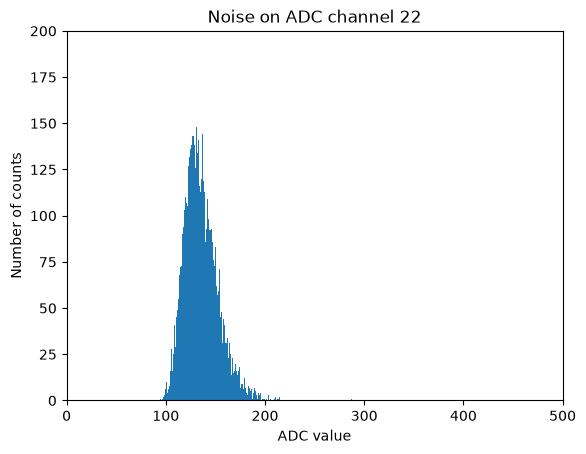

In [100]:
fig, ax = plt.subplots(1, 1)
plot_hist_on(ax, n_list[0], 0)

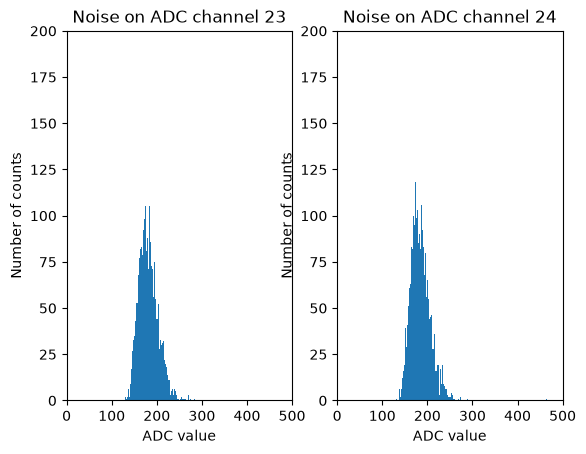

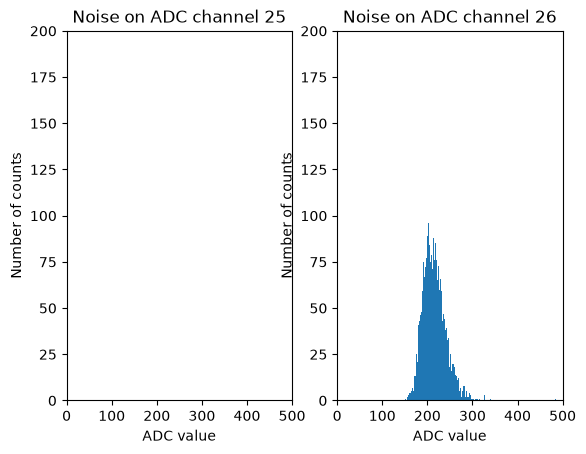

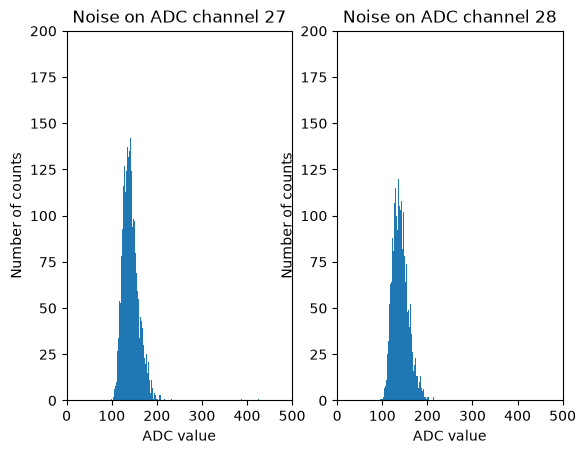

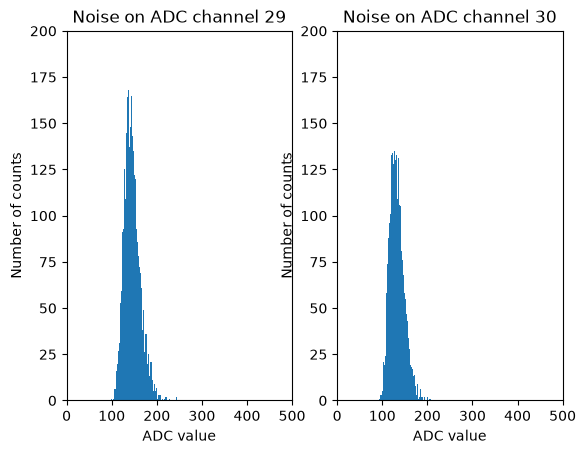

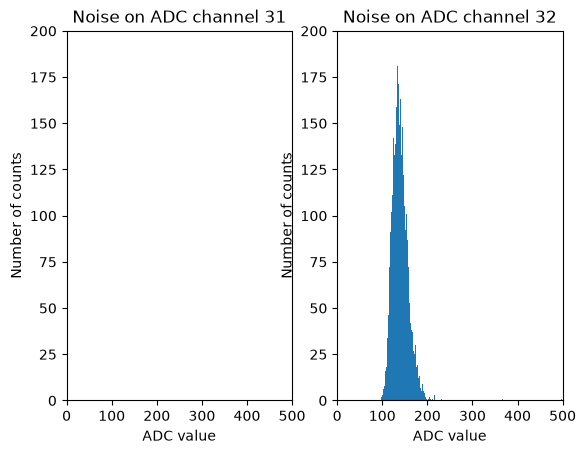

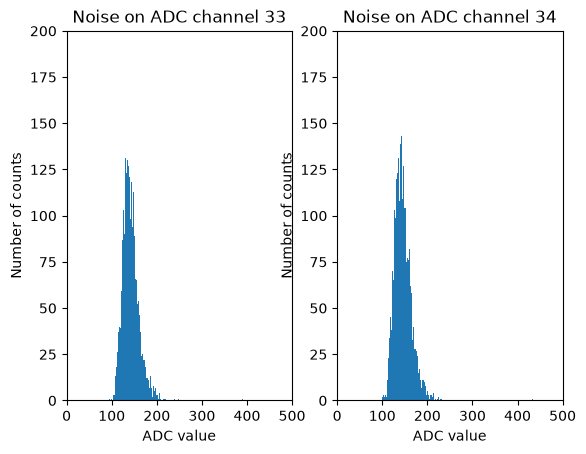

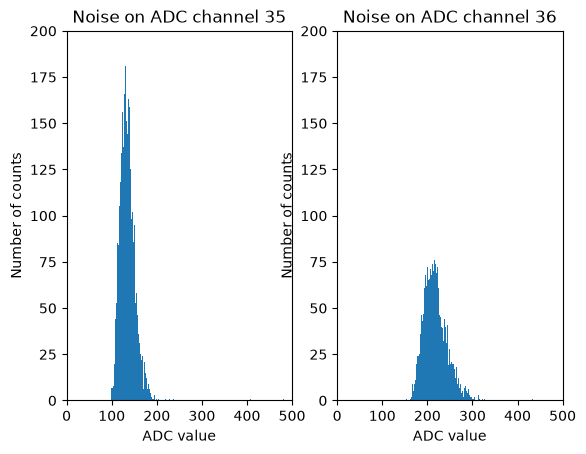

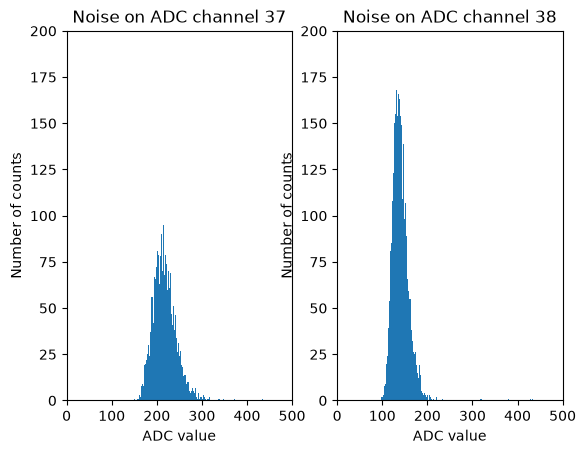

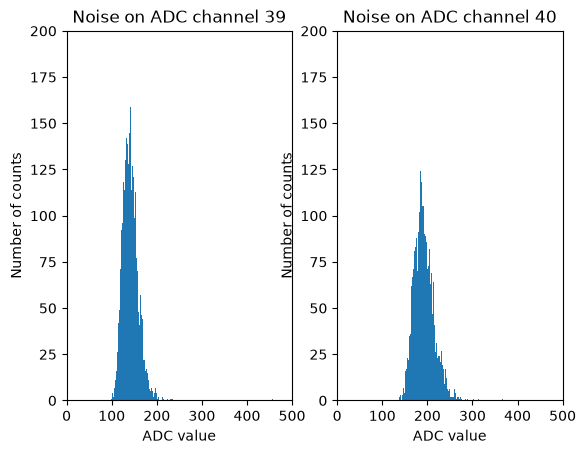

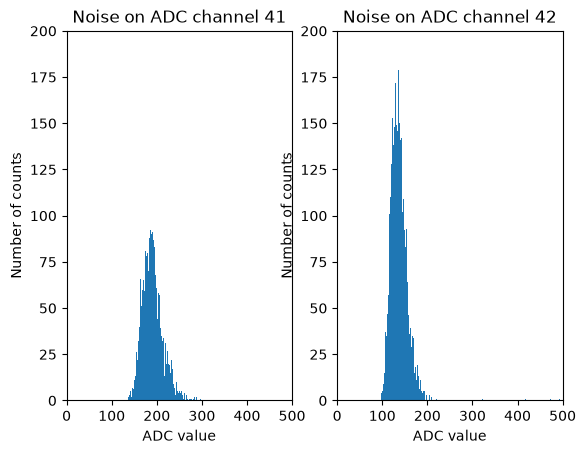

In [101]:
idx = 0
for j in range(10):
    fig, axes = plt.subplots(1, 2)
    for i in range(2):
        idx = 2 * j + i + 1
        plot_hist_on(axes[i], n_list[idx], idx)

Well, there is quite a lot of variety there! The good ones have noise in the 100-200 range. The noisy ones are more like 200-300. Then there are the blank ones. What is in them?

In [107]:
print(n_list[3][:10])

[-9.09480824e-14 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14
 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14
 -9.09480824e-14 -9.09480824e-14]


In [108]:
print(n_list[3][:9])

[-9.09480824e-14 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14
 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14 -9.09480824e-14
 -9.09480824e-14]


OH! What went wrong there? I believe that those are two of the shorted channels.

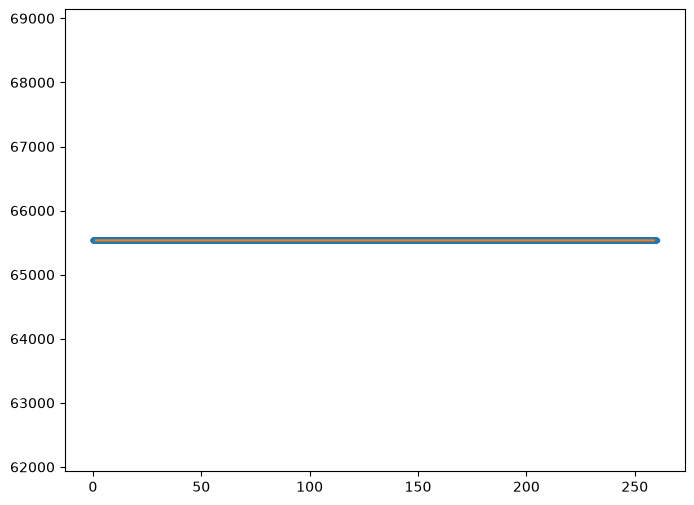

In [18]:
e30, i30 = rd.find_one_edge(0, 3, plot=True)

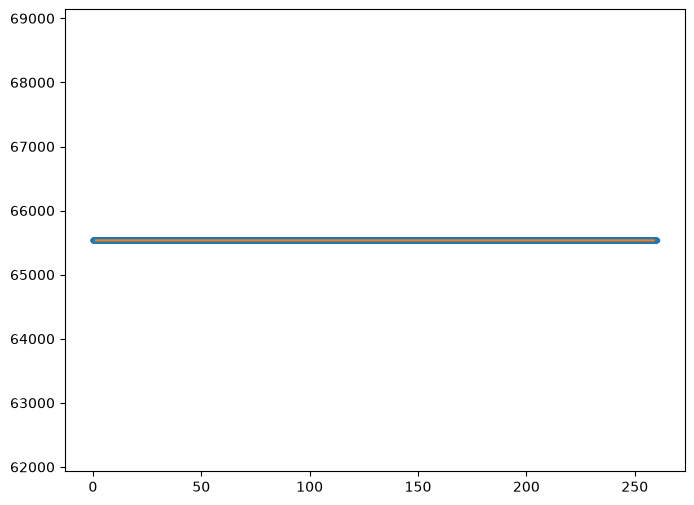

In [19]:
e31, i31 = rd.find_one_edge(1, 3, plot=True)

Well, that would be the problem! These are two of the shorted pixels.